In [41]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import os
import json
import cloudpickle
import sys
sys.path.append(os.path.abspath(".."))
import os
os.environ["JAX_PLATFORMS"] = "cpu"
from IPython.display import FileLink, display, HTML
from mail import *
import jax
import jax.numpy as jnp
print(jax.devices())  # Should list CPU devices only
from plot_utils import plot_experiments, load_run_data, make_table
import matplotlib.pyplot as plt
import numpy as np
from core.configs import CONFIG_REGISTRY


discrete_expl_envs = ["Chain", "Pong-misc", "FourRoomsCustom-v0", "SpaceInvaders-MinAtar", "Breakout-MinAtar", "Freeway-MinAtar", "Asterix-MinAtar", "DeepSea-bsuite", "SparseMountainCar-v0"]
envs = sorted(discrete_expl_envs)

# --- Define runs once ---
RUNS = [
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "Continuing with Opt Init", "color": "black", "alpha": 0.4},
    {"run_dir": "3_13_cov_lstd/cont_no_opt_init", "name": "Continuing no opt init", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_no_opt_init", "name": "Episodic No Opt Init", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/ep_opt_init", "name": "Episodic Opt Init", "color": "#b88027", "alpha": 0.75},
]


def plot_all(RUNS, envs=envs, figsize=(12,4), n_rows=2, n_cols=5):


    plt.style.use('seaborn-v0_8-paper')
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    handles, labels = [], []

    for i, ENV in enumerate(envs):
        ax = axes[i]

        try:
            for run in RUNS:
                config, metrics = load_run_data(run["run_dir"], ENV)

                # Average across seeds if needed
                if run["name"] == "PPO":
                    metrics_avg = jax.tree.map(lambda x: x.mean(0), metrics)
                    rets = metrics_avg['returned_discounted_episode_returns']
                else:
                    rets = metrics['returned_discounted_episode_returns'].mean(0)

                line, = ax.plot(
                    rets,
                    label=run["name"],
                    color=run.get("color", None),
                    alpha=run.get("alpha", 1.0),
                    linewidth=2.5,
                )

                # Save legend handles once
                if i == 0:
                    handles.append(line)
                    labels.append(run["name"])

            # --- Formatting ---
            ax.set_title(ENV, fontweight='bold', fontsize=10)

            row = i // n_cols
            col = i % n_rows

            # X labels only on bottom row
            if row == 3:
                ax.set_xlabel('Training Steps', fontsize=8)
            else:
                ax.set_xlabel('')

            # Y labels only on left column
            if col == 0:
                ax.set_ylabel('Returns', fontsize=9)
            else:
                ax.set_ylabel('')

            ax.grid(True, linestyle='--', alpha=0.6)

        except Exception as e:
            ax.text(0.5, 0.5, f"Missing\n{ENV}", ha='center')
            print(f"Error loading {ENV}: {e}")

    # --- Shared legend ---
    fig.legend(
        handles, labels,
        loc='upper center',
        ncol=len(RUNS),
        bbox_to_anchor=(0.5, -0.1),
        frameon=True,
        fontsize=8
    )
    
    return fig

    # fig.savefig('../figures/debug_results_with_cont.pdf', bbox_inches='tight', dpi=300)
    # email_pdf('../figures/debug_results_with_cont.pdf')

[CudaDevice(id=0)]


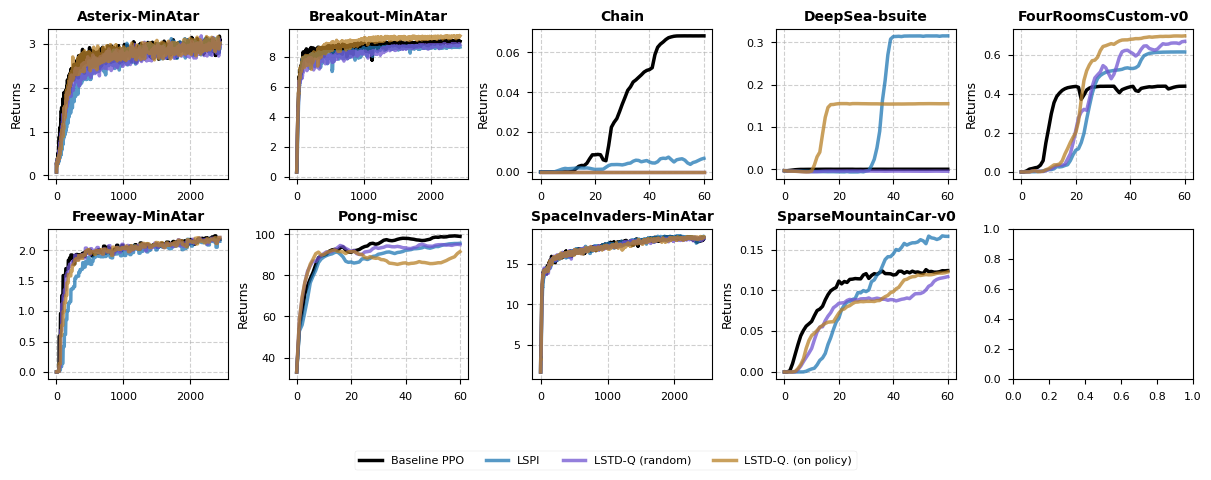

In [23]:
runs = [
    {"run_dir": "3_13_cov_lstd/baseline_ppo", "name": "Baseline PPO", "color": "black", "alpha": 1.0},
    {"run_dir": "3_23_cov_lspi/ep", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/ep", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/ep", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

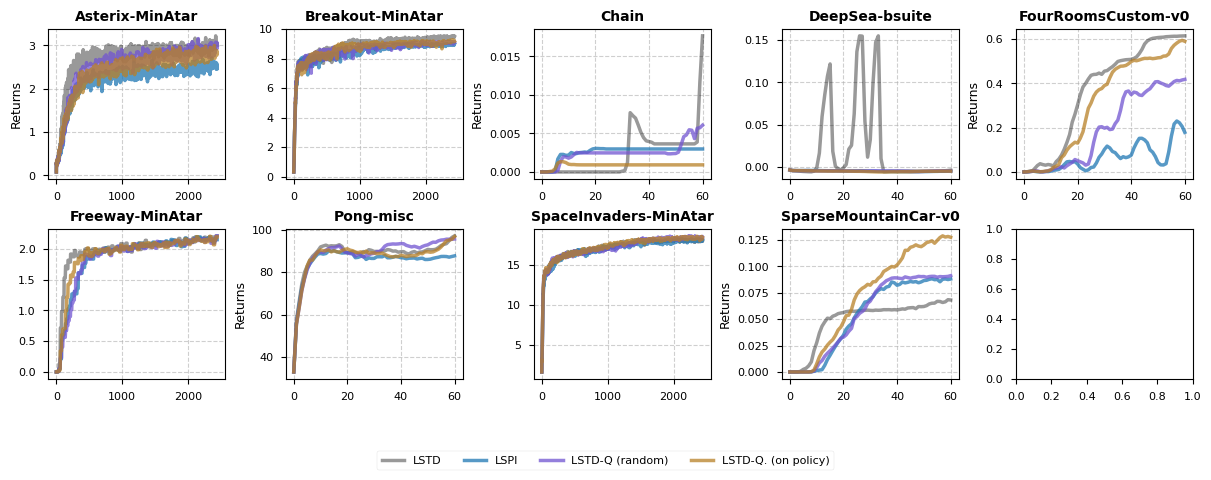

In [24]:
runs = [
    {"run_dir": "3_18_cov_lstd/ep_2", "name": "LSTD", "color": "black", "alpha": 0.4},
    {"run_dir": "3_23_cov_lspi/ep_opt_init", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/ep_opt_init", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/ep_opt_init", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

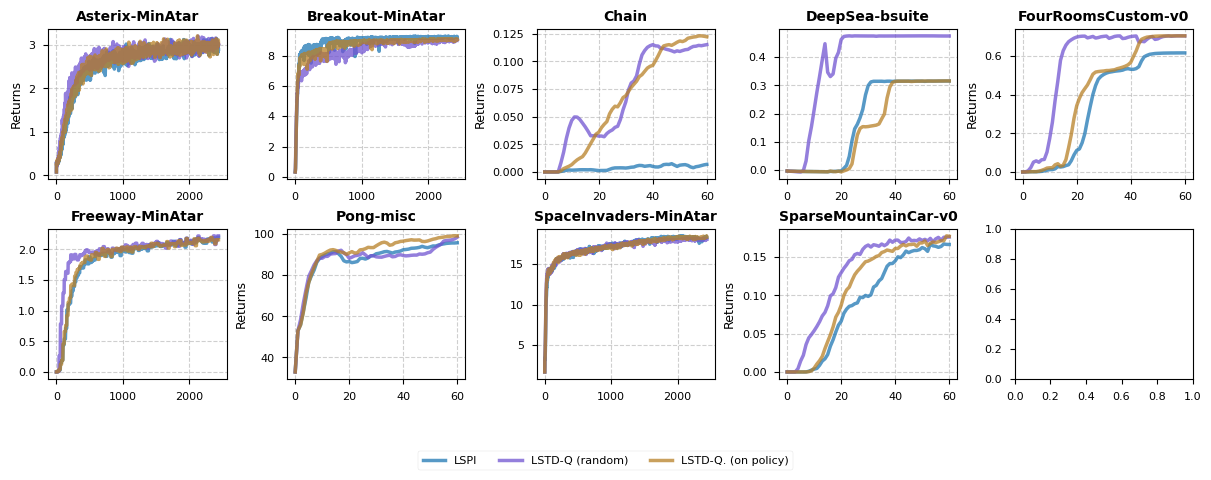

In [25]:
runs = [
    # {"run_dir": "3_18_cov_lstd/cont_2", "name": "LSTD", "color": "black", "alpha": 0.4},
    {"run_dir": "3_23_cov_lspi/cont", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/cont", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

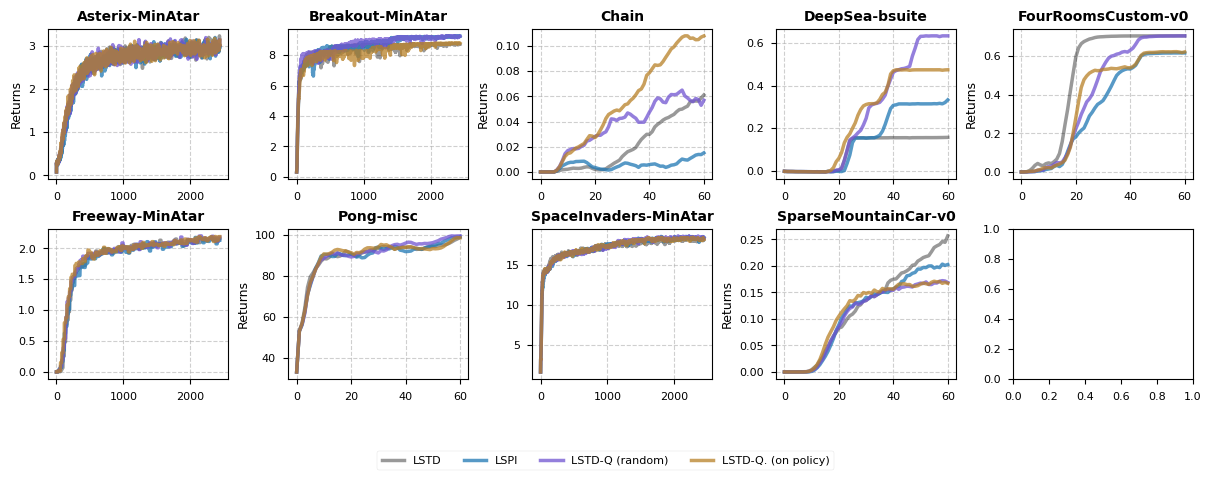

In [58]:
runs = [
    {"run_dir": "3_18_cov_lstd/cont_2", "name": "LSTD", "color": "black", "alpha": 0.4},
    {"run_dir": "3_23_cov_lspi/cont_opt_init", "name": "LSPI", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/cont_opt_init", "name": "LSTD-Q (random)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont_opt_init", "name": "LSTD-Q. (on policy)", "color": "#b88027", "alpha": 0.75},
]

plot_all(runs)

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def generate_performance_heatmap(all_runs, env_list, ppo_run_dir):
    results = []
    
    for env in env_list:
        # 1. Load Baseline PPO for this env
        _, ppo_metrics = load_run_data(ppo_run_dir, env)
        ppo_val = jnp.mean(ppo_metrics['returned_discounted_episode_returns'][:, -10:])
        
        for run in all_runs:
            try:
                _, metrics = load_run_data(run["run_dir"], env)
                # Mean of last 10 steps across all seeds
                run_val = jnp.mean(metrics['returned_discounted_episode_returns'][:, -10:])
                
                # Symmetric Normalization [-1, 1]
                score = (run_val - ppo_val) / (abs(run_val) + abs(ppo_val) + 1e-6)
                
                results.append({
                    "Env": env,
                    "Alg": run["alg"],
                    "Ablation": f"{run['form']} + {run['init']}",
                    "Score": float(score)
                })
            except Exception as e:
                print(f"Skipping {run['run_dir']} for {env}: {e}")

    df = pd.DataFrame(results)
    
    # Aggregate across environments (Mean or Median)
    summary_table = df.pivot_table(
        index="Alg", 
        columns="Ablation", 
        values="Score", 
        aggfunc="mean" # or "median"
    )
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.heatmap(summary_table, annot=True, cmap="RdYlGn", center=0)
    plt.title("PPO-Relative Performance (Last 10 Steps Mean)")
    plt.show()

    return summary_table

In [14]:
# Metadata for all 14 variants
ALL_RUNS = [
    # LSPI variants
    {"run_dir": "3_23_cov_lspi/ep", "alg": "LSPI", "form": "Ep", "init": "No-Opt"},
    {"run_dir": "3_23_cov_lspi/ep_opt_init", "alg": "LSPI", "form": "Ep", "init": "Opt"},
    {"run_dir": "3_23_cov_lspi/cont", "alg": "LSPI", "form": "Cont", "init": "No-Opt"},
    {"run_dir": "3_23_cov_lspi/cont_opt_init", "alg": "LSPI", "form": "Cont", "init": "Opt"},
    
    # LSTD-Q (Random) variants
    {"run_dir": "3_23_cov_lstd_q/ep", "alg": "LSTD-Q (Random)", "form": "Ep", "init": "No-Opt"},
    {"run_dir": "3_23_cov_lstd_q/ep_opt_init", "alg": "LSTD-Q (Random)", "form": "Ep", "init": "Opt"},
    {"run_dir": "3_23_cov_lstd_q/cont", "alg": "LSTD-Q (Random)", "form": "Cont", "init": "No-Opt"},
    {"run_dir": "3_23_cov_lstd_q/cont_opt_init", "alg": "LSTD-Q (Random)", "form": "Cont", "init": "Opt"},

    # LSTD-Q (On-Policy) variants
    {"run_dir": "3_23_cov_lstd_q_on_policy/ep", "alg": "LSTD-Q (π)", "form": "Ep", "init": "No-Opt"},
    {"run_dir": "3_23_cov_lstd_q_on_policy/ep_opt_init", "alg": "LSTD-Q (π)", "form": "Ep", "init": "Opt"},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont", "alg": "LSTD-Q (π)", "form": "Cont", "init": "No-Opt"},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont_opt_init", "alg": "LSTD-Q (π)", "form": "Cont", "init": "Opt"},

    # LSTD variants (The one with only 2 runs)
    {"run_dir": "3_18_cov_lstd/ep", "alg": "LSTD", "form": "Ep", "init": "No-Opt"},
    {"run_dir": "3_18_cov_lstd/ep_opt_init", "alg": "LSTD", "form": "Ep", "init": "Opt"},
    {"run_dir": "3_18_cov_lstd/cont_opt_init", "alg": "LSTD", "form": "Cont", "init": "Opt"},
    {"run_dir": "3_18_cov_lstd/cont", "alg": "LSTD", "form": "Cont", "init": "No-Opt"},
]

# Set your baseline path
PPO_RUN_DIR = "3_13_cov_lstd/baseline_ppo"

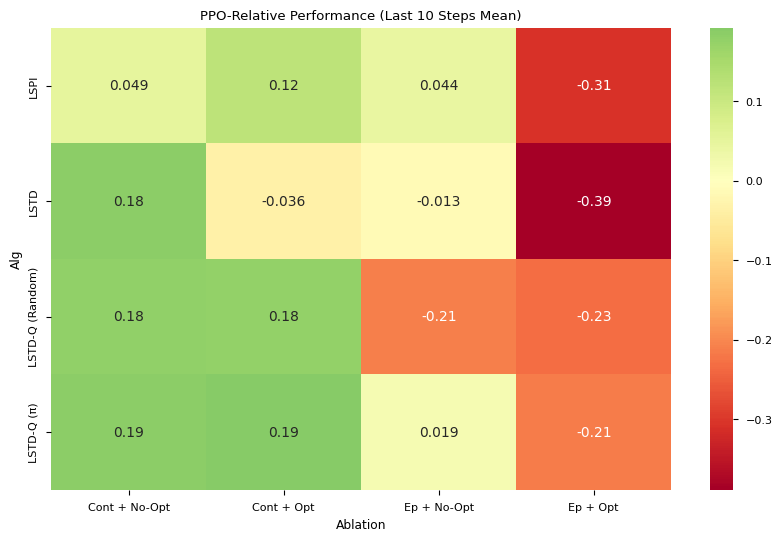

Ablation,Cont + No-Opt,Cont + Opt,Ep + No-Opt,Ep + Opt
Alg,,,,
LSPI,0.048744,0.119454,0.044077,-0.308860
LSTD,0.184810,-0.035997,-0.013037,-0.388833
LSTD-Q (Random),0.180634,0.175686,-0.210164,-0.230728
LSTD-Q (π),0.185539,0.192403,0.019446,-0.211751


In [33]:
summary_table = generate_performance_heatmap(ALL_RUNS, envs, PPO_RUN_DIR)
from mail import email_pdf
summary_table

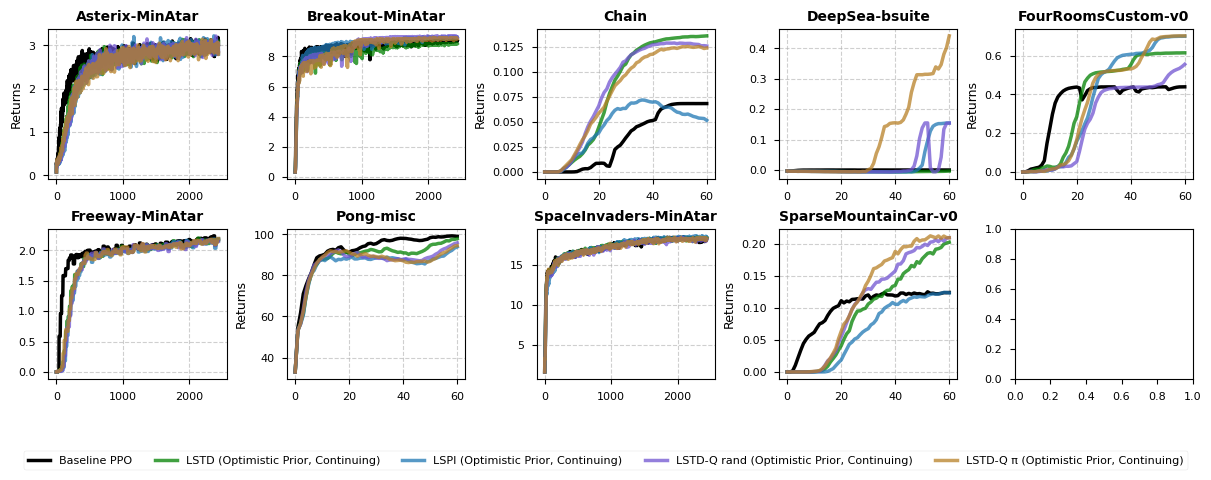

In [ ]:
# continuing, optimistic
runs = [
    {"run_dir": "3_13_cov_lstd/baseline_ppo", "name": "Baseline PPO", "color": "black", "alpha": 1.0},
    {"run_dir": "3_18_cov_lstd/cont_opt_init", "name": "LSTD (Opt. Prior, Continuing)", "color": "green", "alpha": 0.75},
    {"run_dir": "3_23_cov_lspi/cont_opt_init", "name": "LSPI (Opt. Prior, Continuing)", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/cont_opt_init", "name": "LSTD-Q rand (Opt. Prior, Continuing)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont_opt_init", "name": "LSTD-Q π (Opt. Prior, Continuing)", "color": "#b88027", "alpha": 0.75},
    # {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "LSTD (Rmax Opt., Continuing)", "color": "#ff0080", "alpha": 0.75},
    # {"run_dir": "3_23_cov_lstd_q_on_policy/cont_opt_init", "name": "LSTD-Q π (Opt. Prior, Continuing)", "color": "#ec6316", "alpha": 0.75},
]

plot_all(runs)
ema

Error loading Acrobot-v1: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/cont_opt_init/Acrobot-v1/config.json'
Error loading PointRobot-misc: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/cont_opt_init/PointRobot-misc/config.json'
Error loading Reacher-misc: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/cont_opt_init/Reacher-misc/config.json'
Error loading Swimmer-misc: [Errno 2] No such file or directory: '../results/3_18_cov_lstd/cont_opt_init/Swimmer-misc/config.json'


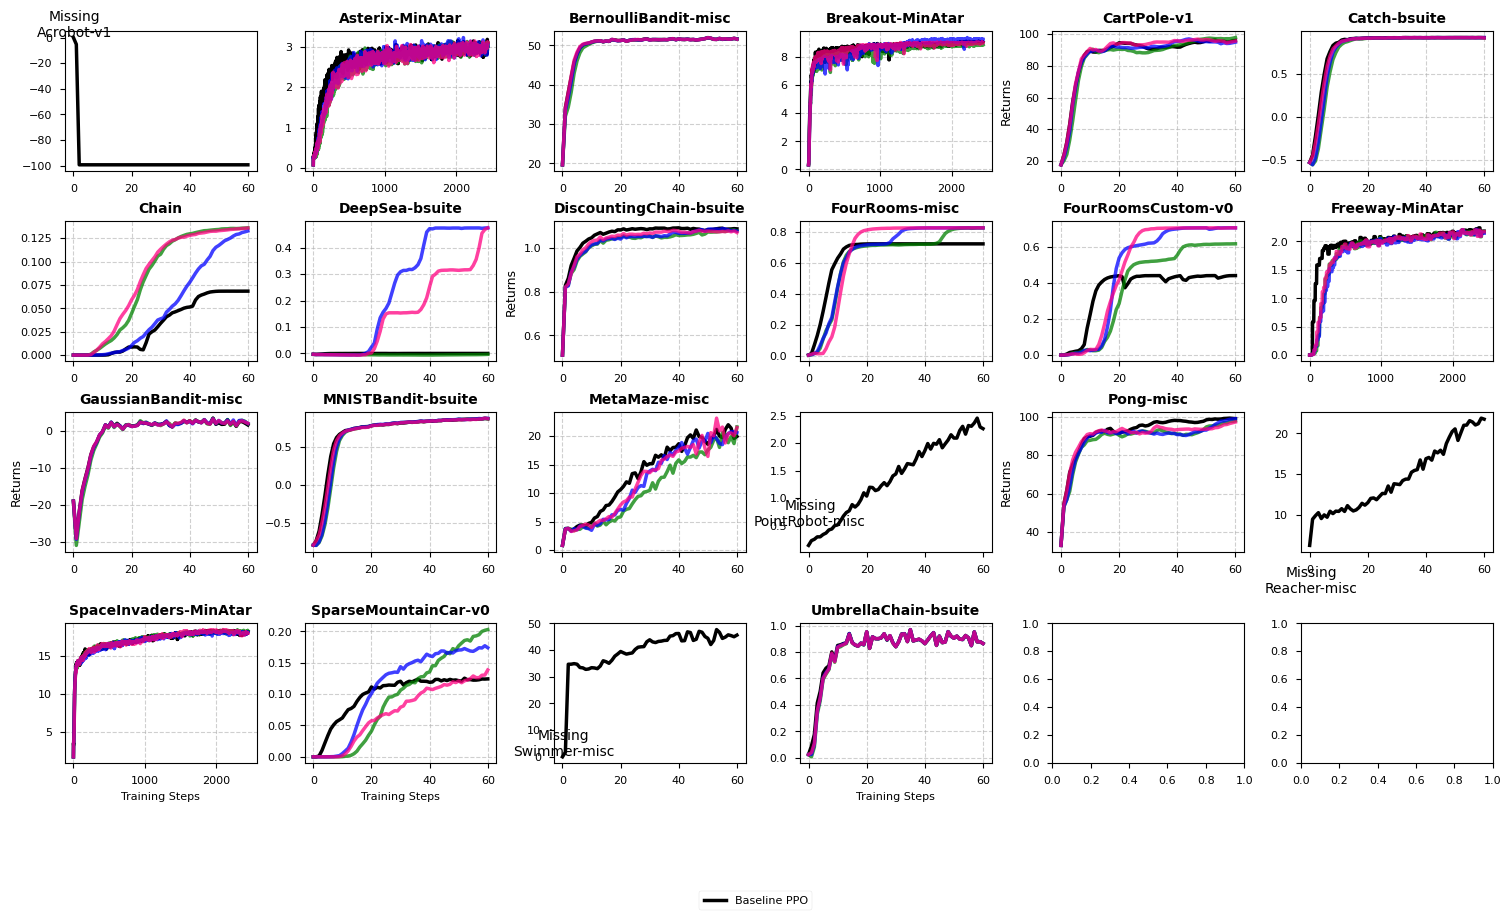

In [ ]:
# Continuous Envs:

from core.configs import CONFIG_REGISTRY

all_envs = set()
for k in CONFIG_REGISTRY:
    all_envs = all_envs.union(set(CONFIG_REGISTRY[k]['envs']))
all_envs = sorted(all_envs)

runs = [
    {"run_dir": "3_13_cov_lstd/baseline_ppo", "name": "Baseline PPO", "color": "black", "alpha": 1.0},
    {"run_dir": "3_18_cov_lstd/cont_opt_init", "name": "LSTD (Opt Prior, Continuing)", "color": "green", "alpha": 0.75},
    {"run_dir": "3_18_cov_lstd/cont", "name": "LSTD (Continuing)", "color": "blue", "alpha": 0.75},
    {"run_dir": "3_13_cov_lstd/cont_opt_init", "name": "LSTD (Rmax Opt, Continuing)", "color": "#ff0080", "alpha": 0.75},
    
]

plot_all(runs, all_envs, figsize=(15, 8), n_rows=4, n_cols=6)
# len(all_envs)

📁 Found ../figures/continuing_lspi_curves.pdf (212.8 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

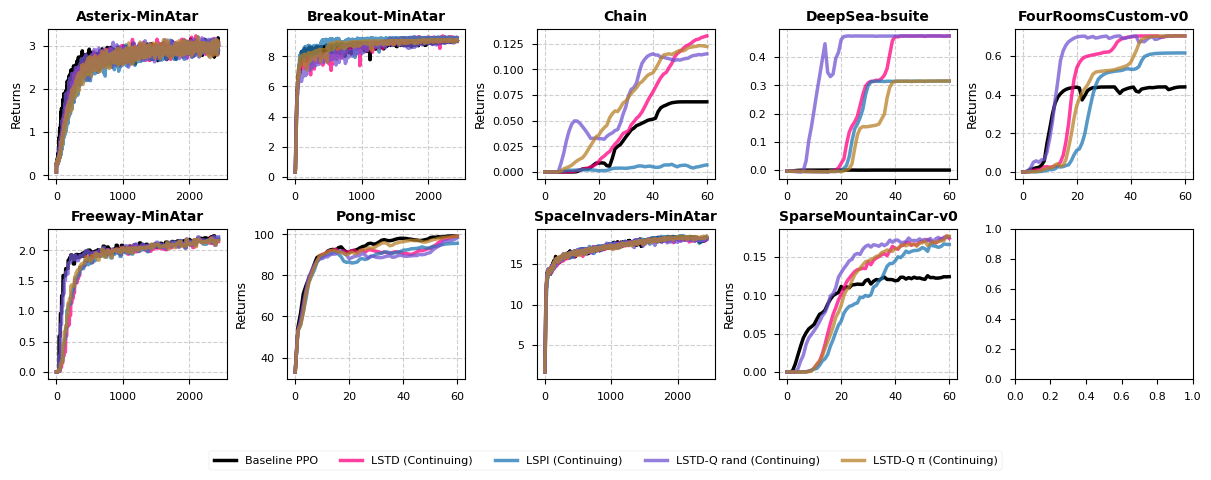

In [42]:
# continuing, no optimism
runs = [
    {"run_dir": "3_13_cov_lstd/baseline_ppo", "name": "Baseline PPO", "color": "black", "alpha": 1.0},
    {"run_dir": "3_18_cov_lstd/cont", "name": "LSTD (Continuing)", "color": "#ff0080", "alpha": 0.75},
    {"run_dir": "3_23_cov_lspi/cont", "name": "LSPI (Continuing)", "color": "#1f77b4", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q/cont", "name": "LSTD-Q rand (Continuing)", "color": "#7154d1", "alpha": 0.75},
    {"run_dir": "3_23_cov_lstd_q_on_policy/cont", "name": "LSTD-Q π (Continuing)", "color": "#b88027", "alpha": 0.75},
    
    # {"run_dir": "3_23_cov_lstd_q_on_policy/cont", "name": "LSTD-Q π (Optimistic Prior, Continuing)", "color": "#ec6316", "alpha": 0.75},
]

fig = plot_all(runs)
fig.savefig( '../figures/continuing_lspi_curves.pdf', bbox_inches='tight', dpi=300)
email_pdf('../figures/continuing_lspi_curves.pdf')

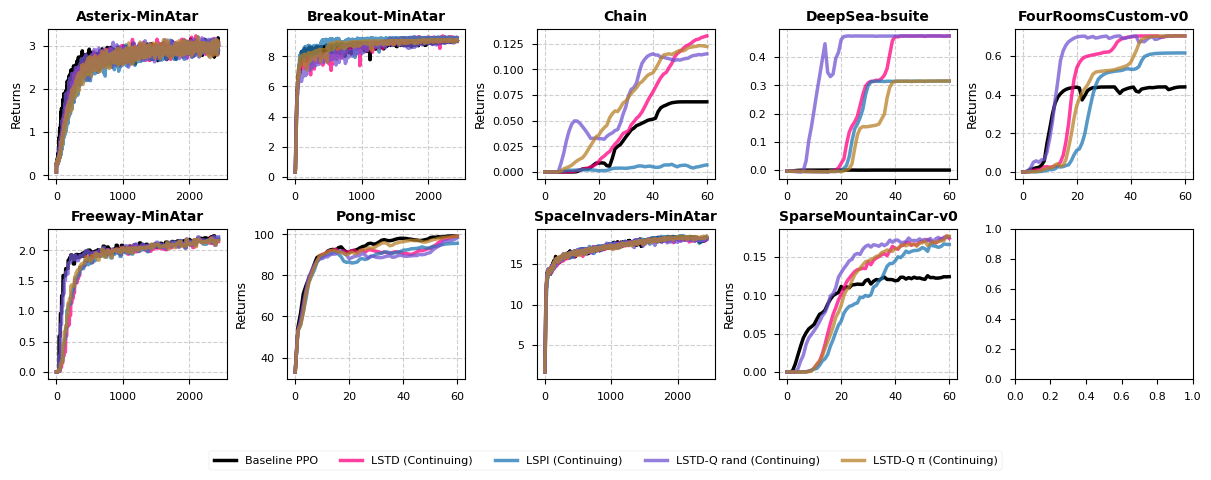